# Life Insurance Premium Calculator

Given a mortality table, this model prices and values life-contingent products, inspired by life-contingent related SOA Exam FAM materials 

**Functionality**: 

1. Actuarial present value of 9 life-contingent products — whole life, term, deferred term, endowment and pure endowment insurance;
   whole life and term annuities (both due and immediate)

2. Net Premiums

3. Policy Value

4. Annual projection of cash flows 

5. Profit testing

6. Interest sensitivity

**Data & assumptions**: SOA Standard Ultimate Life Table (SULT), ages 20-100; annual premiums payable at the start of each year; net premiums(no expenses or lapses)


**Validation**: core calculations are implemented twice and independently (survival-probability summation and commutation functions), cross-validated to floating-point precision, and benchmarked against the `actuarialmath` library.

This notebook follows a single policy — age 30, 10-year term, death benefit 100,000, i = 5% —
from pricing through to valuation, to show how each part of the model works.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from simulation import simulate_one_policy, simulate_portfolio
from premium_calculator import LifeInsuranceCalculator, load_table
from sensitivity import sensitivity_interest_term, sensitivity_interest_whole_life

df = load_table()
calc = LifeInsuranceCalculator(df)

In the dataframe, l is l_x, which is the amount of lives surviving to age x , qx is the probability that a life aged x dies within the year. This table is truncated at age 100, where 'qx' is set to 1 (all remaining lives are assumed to die within that year)

In [3]:
df.head()

,age,l,qx
0,20,100000.0,0.000250
1,21,99975.0,0.000253
2,22,99949.7,0.000257
3,23,99924.0,0.000262
4,24,99897.8,0.000267


Given that policy holder is at age 30, policy term is 10, interest is 5% and the death benefit is 100,000, how much is the expected payout?

In [4]:
AGE, TERM, PAYMENT, INTEREST = 30, 10, 100_000, 0.05
epv = calc.calculate_term_life(AGE, INTEREST, TERM, PAYMENT)
f"{epv:,.2f}"

'295.16'

A one time payment of 295.16 dollars enable a purchase of 10 year-term life insurance with death benefit of 100,000 dollars. What if the policyholder wants to pay by term? 

In [5]:
P = calc.calculate_net_premium_term_life(AGE, INTEREST, TERM, PAYMENT)
f"{P:,.2f}"

'36.46'

The policyholder could pay 36.46 dollars annually at the beginning of the year for 10 years to acquire the term life insurance contract. The premium paid per year is fixed. However, the mortality rate increases as age increases. Therefore insurance companies want to have reserves for potential payouts in the future years. For every year, the money that goes into the reserve is the actuarial present value of the payout minus the actuarial present value of premiums.


In [6]:
R = calc.project_term_life(AGE, TERM, INTEREST, PAYMENT)
R

,l,qx,tpx,expected_death,expected_premium,net_cash_flow,reserve
age,,,,,,,
30,99727.3,0.000315,1.000000,31.500000,36.456792,4.956792,0.000000
31,99695.8,0.000327,0.999684,32.689671,36.445277,3.755605,6.781774
32,99663.2,0.000341,0.999357,34.078082,36.433359,2.355277,12.704648
33,99629.3,0.000356,0.999017,35.565017,36.420967,0.855950,17.525473
34,99593.8,0.000372,0.998661,37.150202,36.407989,-0.742213,21.088893
35,99556.7,0.000391,0.998289,39.033113,36.394427,-2.638686,23.231623
36,99517.8,0.000412,0.997899,41.113450,36.380206,-4.733244,23.582050
37,99476.7,0.000436,0.997487,43.490440,36.365181,-7.125258,21.849808
38,99433.3,0.000463,0.997052,46.163506,36.349316,-9.814190,17.629621


The net cash flow starts positive and turns negative around age 34: in the early years the level premium exceeds the expected death cost, and the surplus is set aside as reserve; later the cost of claims exceeds the premium, and the accumulated reserve funds the shortfall.

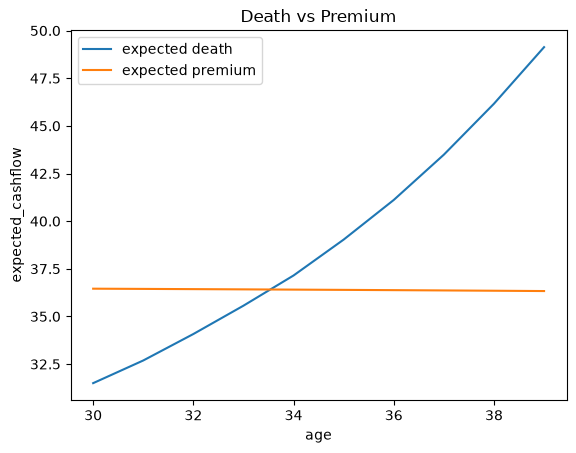

In [7]:
proj = calc.project_term_life(AGE, TERM, INTEREST, PAYMENT)
plt.plot(proj.index, proj['expected_death'], label='expected death')
plt.plot(proj.index, proj['expected_premium'], label='expected premium')
plt.xlabel('age')
plt.ylabel('expected_cashflow')
plt.legend()
plt.title('Death vs Premium')
plt.show()

The expected premium line is almost flat and it reflects the fact that premiums are level. The expected death cost, by contrast, rises steadily, driven by the increasing mortality rate with age. Before the two lines cross at around age 34, premiums exceed the cost of claims, and the surplus is set aside as reserve. After the crossover, claims exceed premiums, and the shortfall is funded by the reserve accumulated in the earlier years.

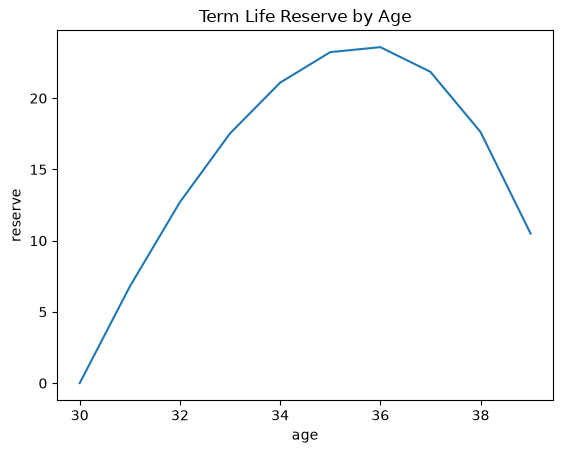

In [8]:
plt.plot(proj.index, proj['reserve'])
plt.xlabel('age')
plt.ylabel('reserve')
plt.title('Term Life Reserve by Age')
plt.show()

The reserve builds up from zero over the first six years, as the level premium exceeds the cost of claims and the surplus is set aside. It peaks around age 36. Reserve starts decreasing around age 36. This shows that the reserve is drawn down to fund claims. 

Because premiums are set by the equivalence principle, the present value of premium income exactly equals the present value of expected claims — under the pricing assumptions, the policy makes no profit at all. Profit therefore arises only when actual experience turns out better than the pricing assumptions: earning a higher investment return than assumed (interest margin), experiencing lower mortality than the table (mortality margin), or incurring lower expenses than loaded into the premium (expense margin). Since this model uses net premiums, it demonstrates the interest margin.

Let say the earn rate is five percent, the profit is zero because the pricing is determined at the interest rate of five percent.

In [9]:
earned_rate = 0.05
P = calc.profit_test_term_life(AGE, TERM, INTEREST, PAYMENT, earned_rate)
P

,l,qx,tpx,expected_death,expected_premium,net_cash_flow,reserve,profit
age,,,,,,,,
30,99727.3,0.000315,1.000000,31.500000,36.456792,4.956792,0.000000,-5.841507e-06
31,99695.8,0.000327,0.999684,32.689671,36.445277,3.755605,6.781774,6.710674e-08
32,99663.2,0.000341,0.999357,34.078082,36.433359,2.355277,12.704648,1.497358e-05
33,99629.3,0.000356,0.999017,35.565017,36.420967,0.855950,17.525473,-6.767036e-06
34,99593.8,0.000372,0.998661,37.150202,36.407989,-0.742213,21.088893,-1.192127e-05
35,99556.7,0.000391,0.998289,39.033113,36.394427,-2.638686,23.231623,6.317266e-06
36,99517.8,0.000412,0.997899,41.113450,36.380206,-4.733244,23.582050,-2.166288e-05
37,99476.7,0.000436,0.997487,43.490440,36.365181,-7.125258,21.849808,-4.990404e-06
38,99433.3,0.000463,0.997052,46.163506,36.349316,-9.814190,17.629621,3.970722e-06


Let say the earn rate becomes six percent. Then, the difference of the earn rate and the interest rate used for pricing is the profit from the policies.

In [10]:
earned_rate = 0.06
P = calc.profit_test_term_life(AGE, TERM, INTEREST, PAYMENT, earned_rate)
P

,l,qx,tpx,expected_death,expected_premium,net_cash_flow,reserve,profit
age,,,,,,,,
30,99727.3,0.000315,1.000000,31.500000,36.456792,4.956792,0.000000,0.364562
31,99695.8,0.000327,0.999684,32.689671,36.445277,3.755605,6.781774,0.432386
32,99663.2,0.000341,0.999357,34.078082,36.433359,2.355277,12.704648,0.491629
33,99629.3,0.000356,0.999017,35.565017,36.420967,0.855950,17.525473,0.539816
34,99593.8,0.000372,0.998661,37.150202,36.407989,-0.742213,21.088893,0.575445
35,99556.7,0.000391,0.998289,39.033113,36.394427,-2.638686,23.231623,0.596890
36,99517.8,0.000412,0.997899,41.113450,36.380206,-4.733244,23.582050,0.600367
37,99476.7,0.000436,0.997487,43.490440,36.365181,-7.125258,21.849808,0.583061
38,99433.3,0.000463,0.997052,46.163506,36.349316,-9.814190,17.629621,0.540868


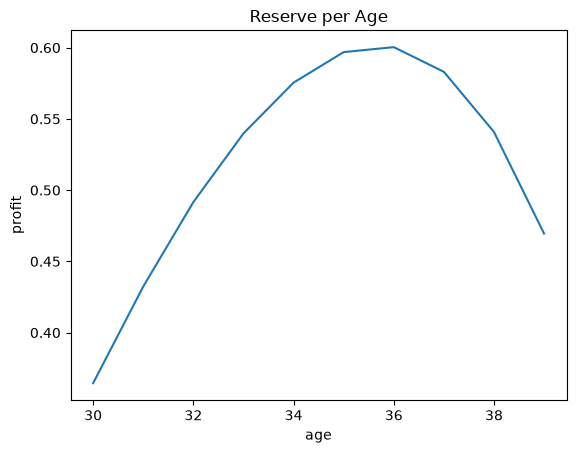

In [11]:
plt.plot(P.index, P['profit'])
plt.xlabel('age')
plt.ylabel('profit')
plt.title('Reserve per Age')
plt.show()


The profit curve mirrors the reserve curve, peaking around age 36. Profit arises purely from the interest margin, the margin is earned on the funds held at the start of each year, i.e. the reserve and premium. 


Every figure so far — present values, premiums, reserves, profit — rests on a single assumption: i = 5%. In reality interest rates move, and an insurer needs to know how much its results would change if that assumption turned out to be wrong. The following section shocks the rate by ±1% and compares how different products respond.

In [12]:
rates = [0.04, 0.05, 0.06]
P = sensitivity_interest_term(calc, AGE, TERM, PAYMENT, rates)
P

,interest,net_premium,reserve_at_t5
0,0.04,36.951451,23.436969
1,0.05,36.456792,23.231623
2,0.06,35.973951,23.021347


Both net premium and reserve are inversely related to the interest rate. If the interest rate decreases, premium needs to be raised in order to have sufficient funds to pay death benefits. 

Reserve = APV(future death benefit) - APV(future premiums)

Both terms rise when rates fall, but not equally. The death benefit is more sensitive to interest rate as it is more weighted towards later years. Because reserve is calculated by subtraction of two bigger numbers. The mismatch is amplified. 

The following section shows how the whole life insurance responds to change in interest rate.

In [13]:
P = sensitivity_interest_whole_life(calc, AGE, PAYMENT, rates)
P 

,interest,A_x,a_due,A_x_pct,a_due_pct
0,0.04,12288.723516,2.280487e+06,59.285407,17.673268
1,0.05,7714.908583,1.937983e+06,0.000000,0.000000
2,0.06,4980.881356,1.678668e+06,-35.438232,-13.380662


A_x = present value of whole life insurance
a_due = present value of whole life annuity due
A_x_pct, a_due_pct = percentage change in value compared to default (interest = 0.05)

Higher interest results in a lower present value of life insurance and annuity products. One thing that is worth mentioning is the percentage change per 100 basis points. 100 bps decrease in interest rate causes 59 percent increase in present value of whole life insurance. 100 basis point increment causes 35 percent decrease in present value of whole life insurance. 

This asymmetry is convexity: present value is a convex function of the interest rate, so a fall in rates increases values by more than an equal rise reduces them. In practice this means insurers are hurt by falling rates far more than they benefit from rising ones, which is why interest rate risk is managed asymmetrically.


In [14]:
calc.reserve_term_life_two_rates(AGE, 0.05, 0.05, TERM, PAYMENT, 0)   
calc.reserve_term_life_two_rates(AGE, 0.05, 0.04, TERM, PAYMENT, 0)   

np.float64(4.166459223902791)

A policy's premium is locked in at the pricing rate when it is sold, but itsreserve must be re-measured at today's rate. If a policy priced at 5% must now be valued at 4%, the reserve at issue is no longer zero. 

## Summary

Under the equivalence principle, premium income and expected claims have equal present value at issue — the policy makes no profit under its own assumptions. Because the premium is level while mortality rises with age, early premiums exceed the cost of claims and the surplus is set aside as reserve; in later years claims exceed premiums and the reserve is drawn down. For a term policy this produces a reserve that rises, peaks, and returns to zero at maturity.

Profit therefore arises only when experience is better than assumed. With net premiums the only source available is the interest margin, and each year's profit is approximately the margin times the funds held at the start of the year — which is why the profit signature mirrors the reserve curve.

Sensitivity to the interest rate scales sharply with duration: a 100 bps fall moves the reserve on a 10-year term policy by under 1%, but the present value of a whole life insurance by 59%. The relationship is convex, so falling rates hurt more than equal rises help. When a policy priced at one rate must be valued at a lower one, a liability appears with no change in mortality or claims — the mechanism behind negative spread.


**Validation.** All present values are computed twice, independently (survival-probability summation and commutation functions), agreeing to floating-point precision, and benchmarked against the `actuarialmath` library. 21 automated tests cover both layers.

**Limitations.** Net premiums only — no expenses, lapses, or mortality improvement. All results are deterministic: the model gives expected values and their sensitivity to assumptions, but not the distribution of outcomes.

In [15]:
for _ in range(15):
    print(simulate_one_policy(calc, 30, 0.05, 10, 100_000))

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [16]:
results = simulate_portfolio(calc, 30, 0.05, 10, 100_000, 100_000)
print(results.mean())
print(results.std())
print((results > 0).mean())

266.4005723354396
4519.698198262289
0.00353


In [17]:
groups = results.reshape(1000, 100)   # 1,000 books of 100 policies each
book_means = groups.mean(axis=1)      # average claim per policy in each book
book_means.std()                      # should be ≈ 4519.7 / √100 ≈ 452

np.float64(439.2807368278517)

In [18]:
results.reshape(10000, 10).mean(axis=1).std()    # books of 10 → expect ≈ 1,430
results.reshape(100, 1000).mean(axis=1).std()    # books of 1,000 → expect ≈ 143

np.float64(129.95040999617828)

A deterministic model gives a single expected value, but says nothing about the
range of outcomes around it. Monte Carlo simulation fills that gap. Simulating
a single policy 100,000 times gives:

- **Mean = 266** — close to the 295 produced by the deterministic model, which
  serves as a third independent check on it (after commutation functions and
  `actuarialmath`). The gap is sampling error: the standard error is 14.3, so
  the two differ by about two standard errors.

- **Standard deviation = 4,519** — seventeen times the mean. A single policy
  pays either nothing or tens of thousands; it never pays 295. The expected
  value is an outcome that never actually occurs.

- **Proportion paying a claim = 0.353%** — consistent with the cumulative
  mortality over the ten-year term. It also explains the size of the sampling
  error above: only 353 of the 100,000 simulations carry any information, which
  makes this a rare-event estimation problem.

- **Law of large numbers** — The same 100,000 simulations can be reinterpreted
  as 1,000 books of 100 policies each. Averaging within each book and taking the
  standard deviation of those averages gives 439 — close to 4,519 / √100 = 452,
  since the standard deviation of an average of N independent policies falls by
  a factor of √N. An individual policy is unpredictable; a large book is not.